# 02 — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
namus_data = pd.read_csv('../data/processed/missing_persons_cleaned.csv')

In [3]:
namus_data.describe(include='all')

,case_number,dlc,legal_last_name,legal_first_name,missing_age,city,county,state,biological_sex,race_ethnicity,date_modified
count,9978,9978,9978,9978,9978.000000,9978,9978,9978,9978,9978,9978
unique,9978,3200,6500,3940,NaN,3028,1024,54,2,67,1576
top,MP160223,2020-08-01,Smith,Michael,NaN,Houston,Harris,TX,Male,White / Caucasian,2025-06-04
freq,1,18,83,151,NaN,371,473,1715,6493,4300,306
mean,NaN,NaN,NaN,NaN,36.135899,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,18.181845,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Create age group variable
namus_data["age_group"] = np.where(namus_data["missing_age"] < 18, "juvenile", "adult")


In [ ]:
# basic stats of the data
namus_data.describe(include='all')

,case_number,dlc,legal_last_name,legal_first_name,missing_age,city,county,state,biological_sex,race_ethnicity,date_modified,age_group
count,9978,9978,9978,9978,9978.000000,9978,9978,9978,9978,9978,9978,9978
unique,9978,3200,6500,3940,NaN,3028,1024,54,2,67,1576,2
top,MP160223,2020-08-01,Smith,Michael,NaN,Houston,Harris,TX,Male,White / Caucasian,2025-06-04,adult
freq,1,18,83,151,NaN,371,473,1715,6493,4300,306,7598
mean,NaN,NaN,NaN,NaN,36.135899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,18.181845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
juveniles = namus_data[namus_data["age_group"] == "juvenile"]
adults = namus_data[namus_data["age_group"] == "adult"]

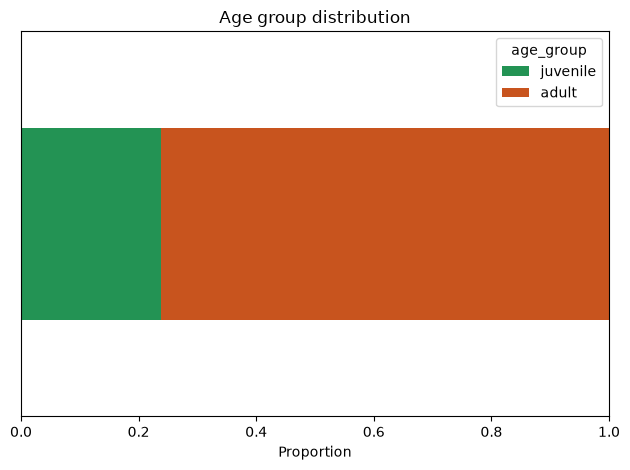

In [7]:
props = (
    namus_data["age_group"]
    .value_counts(normalize=True)
    .reindex(["juvenile", "adult"])
)

props.to_frame().T.plot(
    kind="barh",
    stacked=True,
    color=["#239354", "#C8541E"],  # juvenile, then adult
    legend=True,
)
plt.xlabel("Proportion")
plt.yticks([])
plt.title("Age group distribution")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

This plot shows us the straight up split of Juveniles vs Adults.

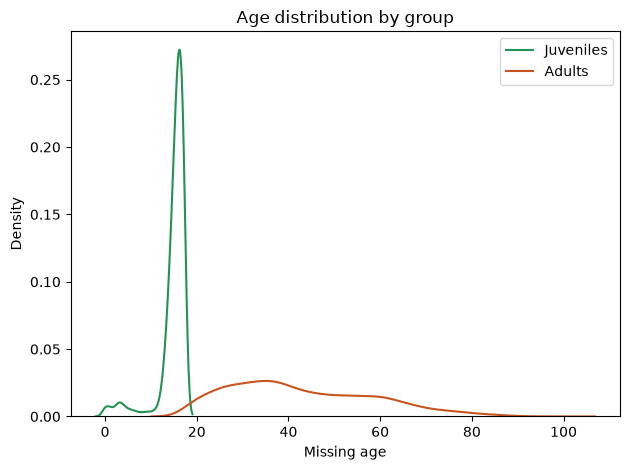

In [8]:
sns.kdeplot(data=juveniles, 
            x="missing_age", 
            label="Juveniles", 
            color="#239354"
)

sns.kdeplot(data=adults, 
            x="missing_age", 
            label="Adults", 
            color="#C8541E"
)
plt.xlabel("Missing age")
plt.ylabel("Density")
plt.title("Age distribution by group")
plt.legend()
plt.tight_layout()
plt.show()

This plot was interesting to me. This shows that among the juvenile group, a vast majority of those going missing are right at that 15,16,17 year old mark. One cause for this could be running away. Many juveniles choose to run away from home for various reasons. I think when interpreting this data we need to understand that many of the juveniles may have chosen to run away from home. Also, though, we do see a bump around 0-10 in juveniles. This is the sad part of this data, these were probably children that were kidnapped or taken from their families. The difference in the spread of distributions is interesting. While juveniles have a massive peak, adults are much more spread out.


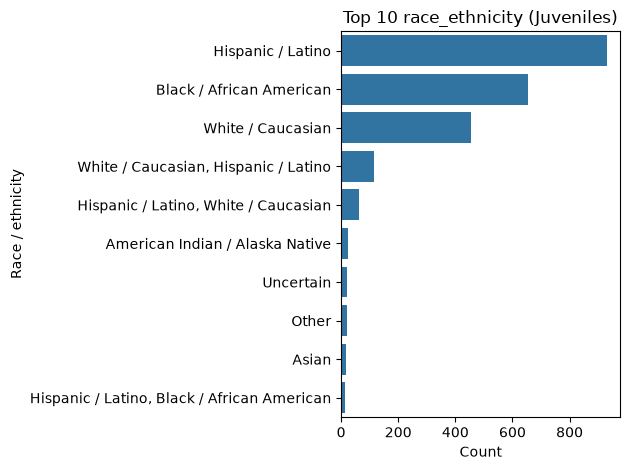

In [9]:
top10_races_juv = juveniles["race_ethnicity"].value_counts().head(10)

sns.barplot(x=top10_races_juv.values, 
            y=top10_races_juv.index
)
plt.xlabel("Count")
plt.ylabel("Race / ethnicity")
plt.title("Top 10 race_ethnicity (Juveniles)")
plt.tight_layout()
plt.show()

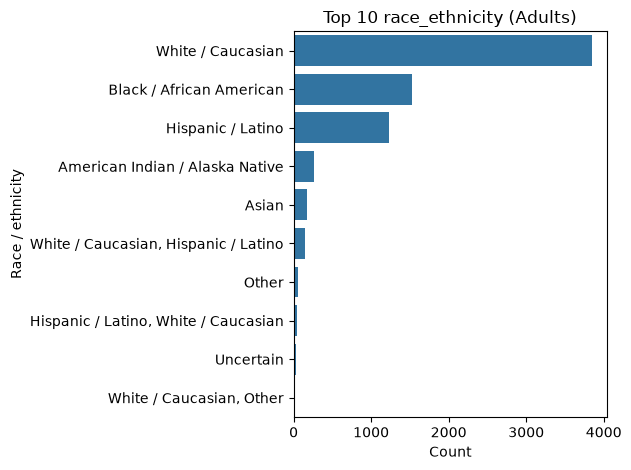

In [10]:
top10_races_adl = adults['race_ethnicity'].value_counts().head(10)

sns.barplot(x=top10_races_adl.values, 
            y=top10_races_adl.index
)
plt.xlabel('Count')
plt.ylabel('Race / ethnicity')
plt.title('Top 10 race_ethnicity (Adults)')
plt.tight_layout()
plt.show()

The difference in race is quite interesting as well. In juveniles, the top race was Hispanic/Latino, while in adults, the top race is White/Caucasian. When first collecting this data, I had an assumption that White/Caucasian would dominate which was clearly proven wrong by the juvenile chart.

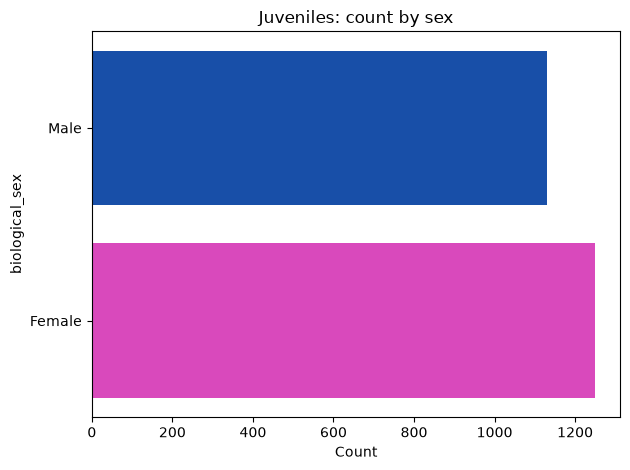

In [11]:
sns.countplot(
    data=juveniles,
    y="biological_sex",
    hue="biological_sex",
    palette={"Male": "#0049C0", "Female": "#F131CB"}
)
plt.xlabel("Count")
plt.title("Juveniles: count by sex")
plt.tight_layout()
plt.show()

Females are the top sex here among the juvenile data. While I don't want to make assumptions, I feel that females are more commonly taken as kids by sick and twisted people. This tracks with what the data shows, but it is not by a large margin.


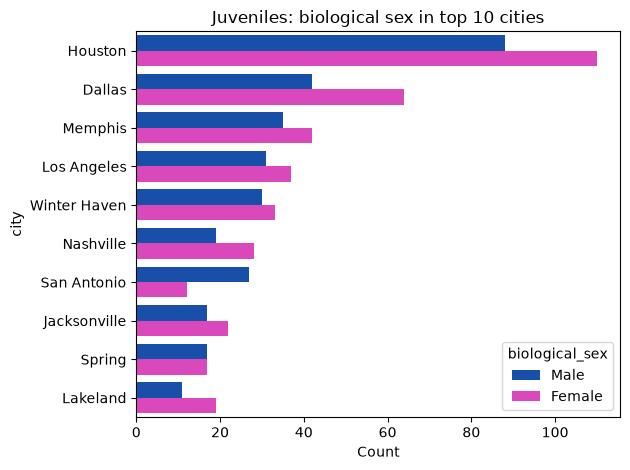

In [12]:
top_cities_juv = juveniles["city"].value_counts().head(10).index
subset = juveniles[juveniles["city"].isin(top_cities_juv)]

sns.countplot(
    data=subset,
    y="city",
    hue="biological_sex",
    order=top_cities_juv,
    palette={"Male": "#0049C0", "Female": "#F131CB"}
)
plt.xlabel("Count")
plt.title("Juveniles: biological sex in top 10 cities")
plt.tight_layout()
plt.show()

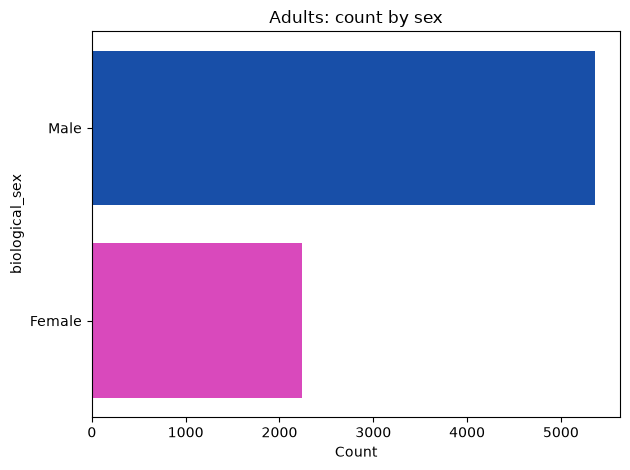

In [13]:
sns.countplot(
    data=adults,
    y="biological_sex",
    hue="biological_sex",
    palette={"Male": "#0049C0", "Female": "#F131CB"}
)
plt.xlabel("Count")
plt.title("Adults: count by sex")
plt.tight_layout()
plt.show()

Males greatly dominate the adults set. While females slightly beat out males in juveniles, males are the top sex in this set.

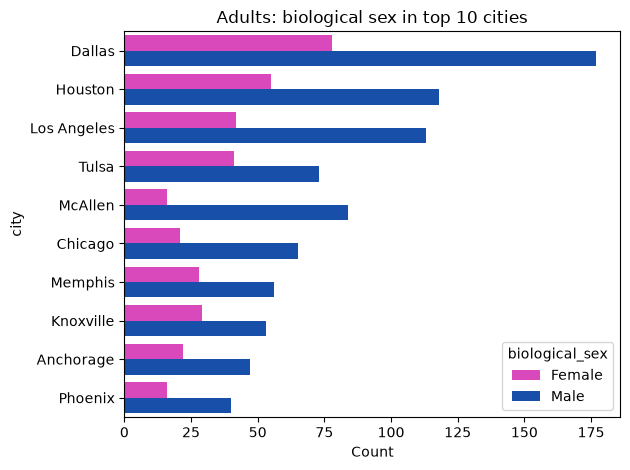

In [14]:
top_cities_adl = adults["city"].value_counts().head(10).index
subset = adults[adults["city"].isin(top_cities_adl)]

sns.countplot(
    data=subset,
    y="city",
    hue="biological_sex",
    order=top_cities_adl,
    palette={"Male": "#0049C0", "Female": "#F131CB"}
)
plt.xlabel("Count")
plt.title("Adults: biological sex in top 10 cities")
plt.tight_layout()
plt.show()

Comparing this with the juvenile list showing the same data, we can see that both Houston and Dallas are the top cities in both sets. This came as a bit of a surprise to me as I considered Texas one of the safer states, but taking everything into perspective, in large metropolitan areas, there is definitely a higher chance of missing people. This is seen in the data as a majority of these top 10 cities are large, well-known cities over various states.


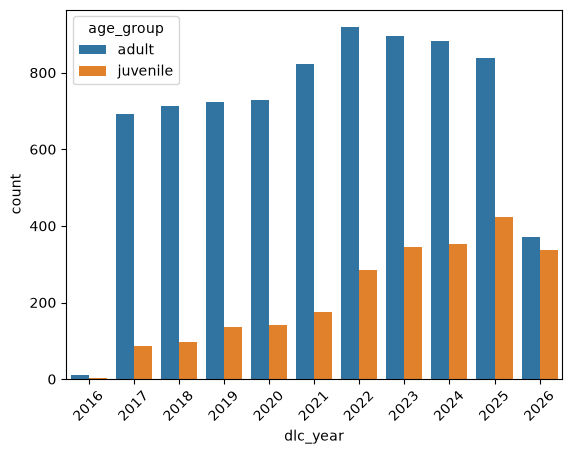

In [15]:
namus_data["dlc"] = pd.to_datetime(namus_data["dlc"])
namus_data["dlc_year"] = namus_data["dlc"].dt.year
years = sorted(namus_data["dlc_year"].unique())

sns.countplot(
    data=namus_data,
    x="dlc_year",
    hue="age_group",
    order=years,
)
plt.xticks(rotation=45)
plt.show()

Here, we can see that after 2020, there seems to be a jump in 2021 and 2022 which is declining among adults but strangely growing among juveniles still. While there may be no causation, Covid started in 2020, and, in 2021, people finally going outside may not have been safe or smart which may have caused that jump in missing persons. The continuous upward slope on the juvenile set is heartbreaking, knowing that more kids each year go missing.


In [16]:
print(namus_data.isna().sum())
print(namus_data.shape)
print(namus_data.describe(include="all"))

case_number         0
dlc                 0
legal_last_name     0
legal_first_name    0
missing_age         0
city                0
county              0
state               0
biological_sex      0
race_ethnicity      0
date_modified       0
age_group           0
dlc_year            0
dtype: int64
(9978, 13)
       case_number                         dlc legal_last_name  \
count         9978                        9978            9978   
unique        9978                         NaN            6500   
top       MP160223                         NaN           Smith   
freq             1                         NaN              83   
mean           NaN  2022-04-05 07:54:48.274203             NaN   
min            NaN         2016-12-26 00:00:00             NaN   
25%            NaN         2020-01-11 12:00:00             NaN   
50%            NaN         2022-07-15 00:00:00             NaN   
75%            NaN         2024-07-19 00:00:00             NaN   
max            NaN         202